# Carga de datos y constantes
En esta sección definimos las constantes del problema y cargamos los datos. Utilizaremos diccionarios para almacenar las valoraciones, ya que permiten un acceso rápido en memoria.

In [ ]:
import csv
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Constantes del problema
NUM_USERS = 1_157_599
NUM_ITEMS = 9541
MIN_RATING = 1.0
MAX_RATING = 5.0
theta = 4.0

def load_data(filepath):
    # defaultdict nos permite inicializar automáticamente valores por defecto.
    # Aquí, si intentamos acceder a un usuario que no existe, nos devolverá un diccionario vacío (dict) 
    # en lugar de lanzar un error (KeyError). Esto agiliza mucho el código.
    ratings = defaultdict(dict)
    with open(filepath, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            u = int(row['user_id'])
            i = int(row['item_id'])
            r = float(row['rating'])
            ratings[u][i] = r
    return ratings

# Cargamos los conjuntos de datos en memoria
ratings = load_data('../dataset/train.csv')
val_ratings = load_data('../dataset/val.csv')
test_ratings = load_data('../dataset/test.csv')

# Para mayor eficiencia en la búsqueda de vecinos, creamos un índice inverso.
# Nos dirá qué usuarios han valorado un ítem en particular.
item_users = defaultdict(list)
for u, items in ratings.items():
    for i in items:
        item_users[i].append(u)


# Funciones de Similaridad
Aquí implementamos las métricas que nos permitirán calcular cómo de parecidos son dos usuarios según sus valoraciones.

In [2]:
def rating_average(u):
    # Calcula la puntuación media dada por el usuario 'u'
    if u not in ratings or not ratings[u]:
        return 0.0
    return sum(ratings[u].values()) / len(ratings[u])

def correlation_similarity(u, v):
    # Similitud de Correlación de Pearson entre usuarios u y v
    items_u = set(ratings[u].keys())
    items_v = set(ratings[v].keys())
    common_items = items_u.intersection(items_v) # Ítems que ambos han valorado
    
    if len(common_items) == 0:
        return 0.0
    
    avg_u = rating_average(u)
    avg_v = rating_average(v)
    
    num = 0.0
    den_u = 0.0
    den_v = 0.0
    
    for i in common_items:
        diff_u = ratings[u][i] - avg_u
        diff_v = ratings[v][i] - avg_v
        num += diff_u * diff_v
        den_u += diff_u ** 2
        den_v += diff_v ** 2
        
    if den_u == 0 or den_v == 0:
        return 0.0
        
    return num / (math.sqrt(den_u) * math.sqrt(den_v))

def jmsd_similarity(u, v):
    # Similitud usando Jaccard multiplicado por 1 - Diferencia Cuadrática Media (MSD)
    items_u = set(ratings[u].keys())
    items_v = set(ratings[v].keys())
    common_items = items_u.intersection(items_v)
    union_items = items_u.union(items_v)
    
    if not common_items:
        return 0.0
        
    # Proporción de ítems en común frente al total de ítems de ambos
    jaccard = len(common_items) / len(union_items)
    
    # Diferencia de valoraciones en los ítems comunes
    sq_diff_sum = sum((ratings[u][i] - ratings[v][i])**2 for i in common_items)
    max_diff_sq = (MAX_RATING - MIN_RATING) ** 2
    msd = sq_diff_sum / len(common_items)
    
    return jaccard * (1 - (msd / max_diff_sq))


# Funciones de Predicción y Vecinos
Estas funciones extraen los k vecinos más cercanos y combinan sus valoraciones para estimar la que daría nuestro usuario objetivo.

In [3]:
def get_neighbors(u, similarities, k):
    # Ordena el diccionario de similitudes de mayor a menor y toma los 'k' mejores
    sorted_sims = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    return sorted_sims[:k]

def average_prediction(u, i, neighbors):
    # Media simple de las valoraciones de los vecinos para el ítem 'i'
    valid_neighbors = [v for v, sim in neighbors if i in ratings[v]]
    if not valid_neighbors:
        return rating_average(u) if u in ratings else global_mean
    return sum(ratings[v][i] for v in valid_neighbors) / len(valid_neighbors)

def weighted_average_prediction(u, i, neighbors):
    # Media ponderada: vecinos más similares tienen mayor peso en la predicción
    num = 0.0
    den = 0.0
    for v, sim in neighbors:
        if i in ratings[v] and sim > 0:
            num += sim * ratings[v][i]
            den += sim
    if den == 0:
        return average_prediction(u, i, neighbors)
    return num / den

def deviation_from_mean_prediction(u, i, neighbors):
    # Predicción considerando la desviación respecto a la media del vecino
    avg_u = rating_average(u)
    num = 0.0
    den = 0.0
    for v, sim in neighbors:
        if i in ratings[v] and sim > 0:
            avg_v = rating_average(v)
            num += sim * (ratings[v][i] - avg_v)
            den += sim
    if den == 0:
        return avg_u if avg_u > 0 else global_mean
    pred = avg_u + (num / den)
    # Limitamos la predicción al rango de notas válidas [1, 5]
    return max(MIN_RATING, min(MAX_RATING, pred))

def get_recommendations(predictions, N):
    # A partir de las predicciones, extraemos los N mejores ítems para cada usuario
    recs = {}
    for u, preds in predictions.items():
        sorted_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)
        recs[u] = [i for i, p in sorted_preds[:N]]
    return recs


# Función Modular del Sistema
Esta es la función principal que orquesta el proceso: busca vecinos y emite predicciones para un conjunto de prueba.

In [4]:
def run_knn(k, metric_func, aggregation_func, target_set):
    predictions = defaultdict(dict)
    
    for u in target_set.keys():
        similarities = {}
        
        # Para no evaluar todo el dataset (lo cual sería lentísimo),
        # solo calculamos similitudes con usuarios que hayan valorado ítems que 'u' también valoró.
        items_u = ratings.get(u, {}).keys()
        candidate_users = set()
        for item in items_u:
            candidate_users.update(item_users.get(item, []))
            
        if u in candidate_users:
            candidate_users.remove(u)
            
        for v in candidate_users:
            sim = metric_func(u, v)
            if sim > 0:
                similarities[v] = sim
                    
        neighbors = get_neighbors(u, similarities, k)
        
        # Para cada ítem a predecir, estimamos su nota
        for i in target_set[u].keys():
            pred = aggregation_func(u, i, neighbors)
            predictions[u][i] = pred
            
    return predictions


# Modelo Base (Baseline)
Calculamos el modelo base para tener un punto de referencia.

In [5]:
global_sum = 0
global_count = 0
for u in ratings:
    for i, r in ratings[u].items():
        global_sum += r
        global_count += 1

global_mean = global_sum / global_count if global_count > 0 else 0
print(f"Media global de entrenamiento: {global_mean:.4f}")

def compute_rmse_baseline(target_set, baseline_pred):
    # Error cuadrático medio del baseline (predecir siempre la media global)
    sq_err = 0.0
    count = 0
    for u in target_set:
        for i, r in target_set[u].items():
            sq_err += (r - baseline_pred)**2
            count += 1
    return math.sqrt(sq_err / count) if count > 0 else 0

baseline_rmse = compute_rmse_baseline(val_ratings, global_mean)
print(f"RMSE Baseline en validación: {baseline_rmse:.4f}")


Media global de entrenamiento: 4.0460
RMSE Baseline en validación: 1.2528


# Ajuste de Parámetros (Tuning Comparativo)
Probamos diferentes configuraciones (K y métricas de similitud) y seleccionamos la que tenga un menor error (RMSE) en el conjunto de validación.

Evaluando correlation_similarity con k=10...
RMSE: 1.4998
Evaluando correlation_similarity con k=25...
RMSE: 1.5009
Evaluando correlation_similarity con k=50...
RMSE: 1.5020
Evaluando jmsd_similarity con k=10...
RMSE: 1.4989
Evaluando jmsd_similarity con k=25...
RMSE: 1.4986
Evaluando jmsd_similarity con k=50...
RMSE: 1.4986


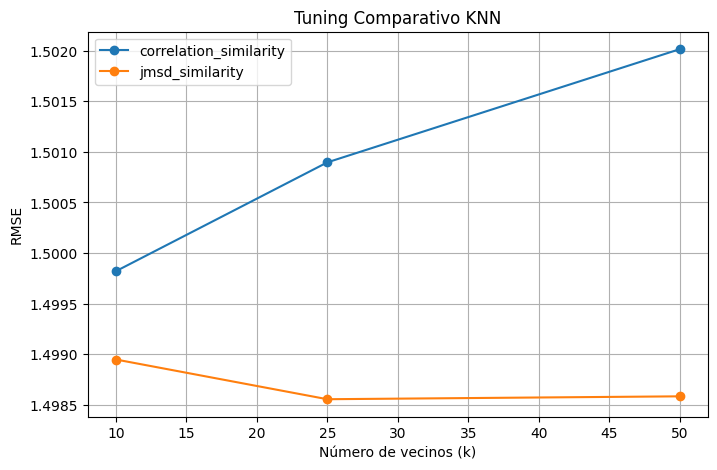

In [6]:
metrics = [
    ('correlation_similarity', correlation_similarity),
    ('jmsd_similarity', jmsd_similarity)
]
k_values = [10, 25, 50]

results = {m_name: [] for m_name, _ in metrics}

def compute_rmse(predictions, target_set):
    sq_err = 0.0
    count = 0
    for u in target_set:
        for i, r in target_set[u].items():
            pred = predictions.get(u, {}).get(i, global_mean)
            sq_err += (r - pred)**2
            count += 1
    return math.sqrt(sq_err / count) if count > 0 else 0

# Nota: Para agilizar el ejemplo o realizar una prueba rápida, se puede hacer sampling:
# import random; sample_users = list(val_ratings.keys())[:100]; val_ratings_sample = {u: val_ratings[u] for u in sample_users}
val_ratings_sample = val_ratings # Utilizando todo el conjunto de validación por defecto

for m_name, m_func in metrics:
    for k in k_values:
        print(f"Evaluando {m_name} con k={k}...")
        preds = run_knn(k, m_func, deviation_from_mean_prediction, val_ratings_sample)
        rmse = compute_rmse(preds, val_ratings_sample)
        results[m_name].append(rmse)
        print(f"RMSE: {rmse:.4f}")

# Gráfico comparativo
plt.figure(figsize=(8, 5))
for m_name in results:
    plt.plot(k_values, results[m_name], marker='o', label=m_name)
plt.xlabel('Número de vecinos (k)')
plt.ylabel('RMSE')
plt.title('Tuning Comparativo KNN')
plt.legend()
plt.grid(True)
plt.show()


# Guardado del Modelo
Para evitar reentrenar/recomputar el modelo en la evaluación final, exportaremos los mejores parámetros y diccionarios a la carpeta `models/` usando la librería `pickle`.

In [7]:
# Seleccionamos la mejor configuración automáticamente en base al menor RMSE
best_rmse = float('inf')
best_k = k_values[0]
best_metric_name = metrics[0][0]

for m_name, m_func in metrics:
    for idx, k in enumerate(k_values):
        if results[m_name][idx] < best_rmse:
            best_rmse = results[m_name][idx]
            best_k = k
            best_metric_name = m_name

print(f"Mejor modelo KNN: {best_metric_name} con k={best_k} (RMSE: {best_rmse:.4f})")

import os
import pickle

model_path = '../models/best_knn_model.pkl'

# Guardaremos la configuración óptima para que otros notebooks la puedan consumir directamente
knn_model_data = {
    'best_k': best_k,
    'best_metric_name': best_metric_name,
    'global_mean': global_mean
    # Nota: No serializamos el diccionario 'ratings' completo para evitar archivos excesivamente grandes.
    # El otro notebook (final_comparison) volverá a cargar `train.csv` con nuestra función `load_data`.
}

with open(model_path, 'wb') as f:
    pickle.dump(knn_model_data, f)
    
print(f"Modelo base de hiperparámetros guardado en {model_path}")


Mejor modelo KNN: jmsd_similarity con k=25 (RMSE: 1.4986)
Modelo base de hiperparámetros guardado en ../models/best_knn_model.pkl
